In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
dataset = load_digits()
X = dataset.data
Y = dataset.target
Y = np.eye(10)[Y]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((1437, 64), (360, 64), (1437, 10), (360, 10))

In [3]:
def sigmoid(X):
  return 1 / (1 + np.exp(-X))

def softmax(X):
  return np.exp(X) / np.sum(np.exp(X))

def root_mean_squired_error(Y_gt,Y_pred):
  return np.sqrt(np.mean((Y_gt - Y_pred) ** 2))

In [4]:
epochs = 64
η = 0.001
D_in = X_train.shape[1]
H1 = 128
H2 = 32
D_out = Y_train.shape[1]

In [5]:
W1 = np.random.randn(D_in,H1)
W2 = np.random.randn(H1,H2)
W3 = np.random.randn(H2,D_out)

In [6]:
B1 = np.random.randn(1,H1)
B2 = np.random.randn(1,H2)
B3 = np.random.randn(1,D_out)

In [7]:
loss_train_list = []
loss_test_list = []
accuracy_train_list = []
accuracy_test_list = []
for epoch in tqdm(range(epochs)):

  Y_pred_train = []
  #train
  for x,y in zip(X_train,Y_train):
    x = x.reshape(-1 , 1)
    # Forward
    out1 = sigmoid(x.T @ W1 + B1)
    out2 = sigmoid(out1 @ W2 + B2)
    out3 = softmax(out2 @ W3 + B3)
    y_pred = out3
    Y_pred_train.append(y_pred)

    #Back Propagation
    error = -2 * (y - y_pred)
    grad_B3 = error
    grad_W3 = out2.T @ error

    error = error @ W3.T * out2 * (1 - out2)
    grad_B2 = error
    grad_W2 = out1.T @ error

    error = error @ W2.T * out1 * (1 - out1)
    grad_B1 = error
    grad_W1 = x @ error

    #Update
    W1 -= η * grad_W1
    B1 -= η * grad_B1

    W2 -= η * grad_W2
    B2 -= η * grad_B2

    W3 -= η * grad_W3
    B3 -= η * grad_B3

  Y_pred_test = []
  #Test
  for x,y in zip(X_test,Y_test):
    x = x.reshape(-1 , 1)
    # Forward
    out1 = sigmoid(x.T @ W1 + B1)
    out2 = sigmoid(out1 @ W2 + B2)
    out3 = softmax(out2 @ W3 + B3)
    y_pred = out3
    Y_pred_test.append(y_pred)

  Y_pred_train = np.array(Y_pred_train).reshape(-1,10)
  loss_train = root_mean_squired_error(Y_train,Y_pred_train)
  accuracy_train = np.sum(np.argmax(Y_train,axis=1) == np.argmax(Y_pred_train,axis=1)) / len(Y_train)
  loss_train_list.append(loss_train)
  accuracy_train_list.append(accuracy_train)

  Y_pred_test = np.array(Y_pred_test).reshape(-1,10)
  loss_test = root_mean_squired_error(Y_test,Y_pred_test)
  accuracy_test = np.sum(np.argmax(Y_test,axis=1) == np.argmax(Y_pred_test,axis=1)) / len(Y_test)
  loss_test_list.append(loss_test)
  accuracy_test_list.append(accuracy_test)


100%|██████████| 64/64 [00:09<00:00,  6.79it/s]


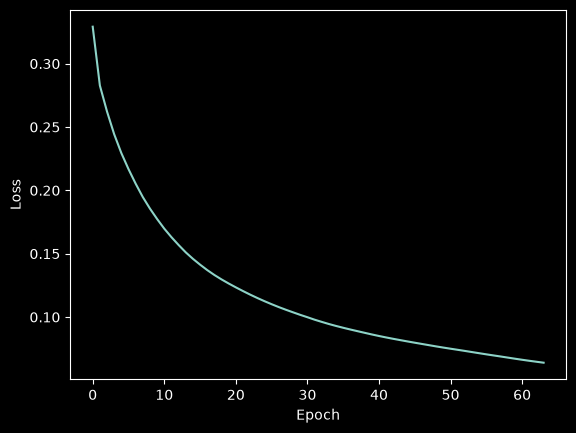

In [9]:
plt.plot(loss_train_list,label='train')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig('output/loss_train.png')
plt.show()

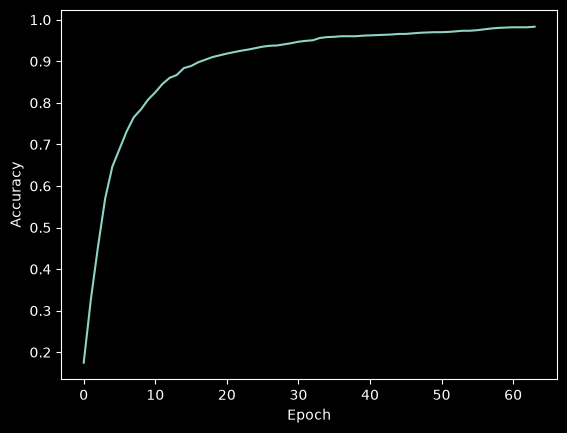

In [10]:
plt.plot(accuracy_train_list,label='train')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig('output/accuracy_train.png')
plt.show()

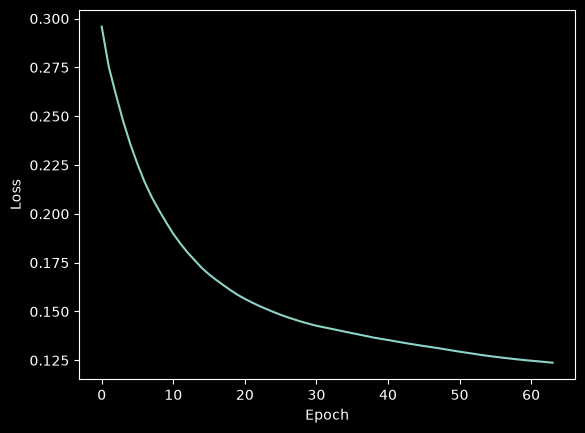

In [11]:
plt.plot(loss_test_list,label='train')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.savefig('output/loss_test.png')
plt.show()

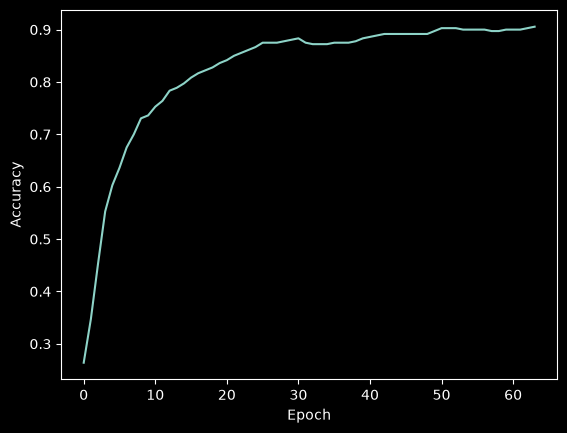

In [12]:
plt.plot(accuracy_test_list,label='train')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.savefig('output/accuracy_test.png')
plt.show()